## Лабораторна робота 6. **Unsupervised Learning**

Оцінювання даної роботи буде ураховувати якість Ваших висновків та візуалізацій. При наявності ЛИШЕ коду та візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.  

Більшість поставлених в цій лабораторній роботі задач в майбутньому буде ставитись Вами самойстійно!

Під час виконання Вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації. 

Оформлення коментарів повинно проводитися в текстових комірках ноутбука з використанням синтаксису [LaTeX](https://en.wikibooks.org/wiki/LaTeX/Basics) для оформлення тексту та формул. 

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

## Кластерування  

В цій лабораторній роботі Ви будете вирішувати задачу класифікації БЕЗ вчителя. 

In [363]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering 
from scipy.cluster import hierarchy 
from scipy.spatial import distance_matrix 
from sklearn.preprocessing import StandardScaler

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline 

import warnings


warnings.filterwarnings('ignore')

**Завдання 0** 

Для початку необхідно завантажити вибірку `Mall_Customers` і перейменувати атрибути `Annual Income (k$)` в `Income`,`Spending Score (1-100)` в `SpendingScore`

In [364]:
class DataLoader:
    def __init__(self, file_path: str):
        self.df: pd.DataFrame = pd.read_csv(file_path)
    
    def get_data(self) -> pd.DataFrame:
        return self.df

In [365]:
data_loader = DataLoader("./datasets/Mall_Customers.csv")

In [366]:
customer_df = data_loader.get_data()

In [367]:
customer_df = customer_df.rename(columns={"Annual Income (k$)": "Income", "Spending Score (1-100)": "SpendingScore"})

**Завдання 1** 

Підготовка даних до опрацювання

* подивитись які атрибути містить вибірка; 
* вивести розмірність датасету;
* вивести основну статистичну інформацію по числовим змінним;  
* перевірити на наявність `NaN`.   

In [368]:
customer_df.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [369]:
customer_df.columns

Index(['CustomerID', 'Gender', 'Age', 'Income', 'SpendingScore'], dtype='object')

In [370]:
customer_df.shape

(200, 5)

In [371]:
customer_df.describe()

,CustomerID,Age,Income,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [372]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   Income         200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [373]:
nan_count = customer_df.isna().sum()

In [374]:
nan_count

CustomerID       0
Gender           0
Age              0
Income           0
SpendingScore    0
dtype: int64

## EDA Mall Customers

**Завдання 2** 

Як Ви могли помітити по статистичній аналітиці вибірки вона містить змінну `CustomerID`. Ця змінна не впливає на аналіз даних тому її можна видалити.

In [375]:
customer_df = customer_df.drop(["CustomerID"], axis=1)

In [376]:
customer_df

,Gender,Age,Income,SpendingScore
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


**Завдання 3** 

Побудувати діаграми розподілу по змінним `Age` , `Income` та `SpendingScore`

In [377]:
class Visualizer:
    def __init__(self, dataset):
        self.df = dataset

    def histplot(self, col_name, color):
        plt.figure(figsize=(12, 7))
        sns.histplot(customer_df[col_name], bins=20, color=color)
        plt.title(f'Distribution of {col_name.capitalize()}')

        plt.show()

In [378]:
visualizer = Visualizer(customer_df)

In [379]:
diagram_columns = ["Age", "Income", "SpendingScore"]
colors = ["#FFD95F", "#B8D576", "#D70654"]

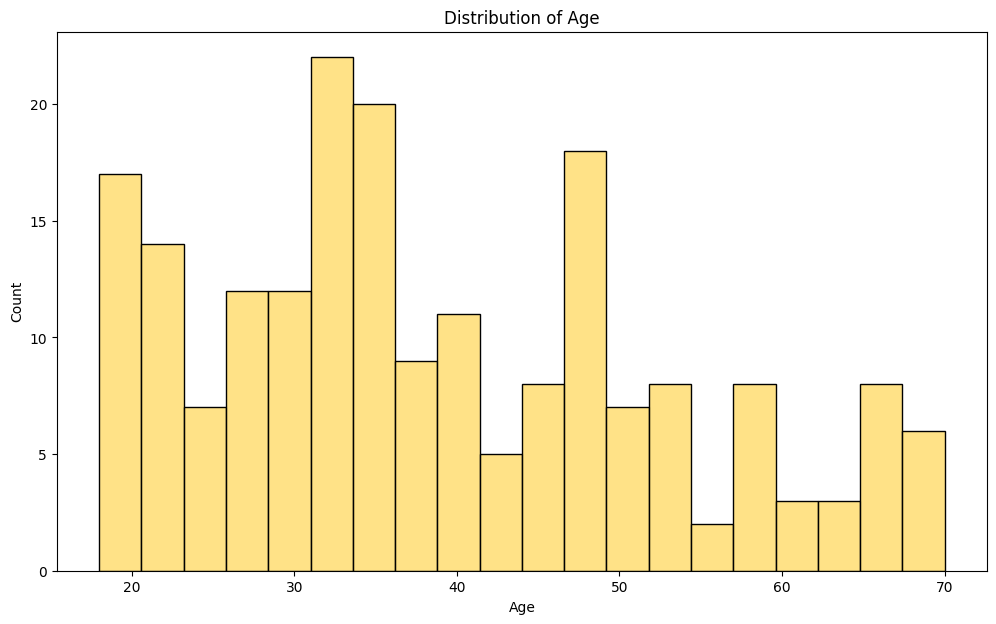

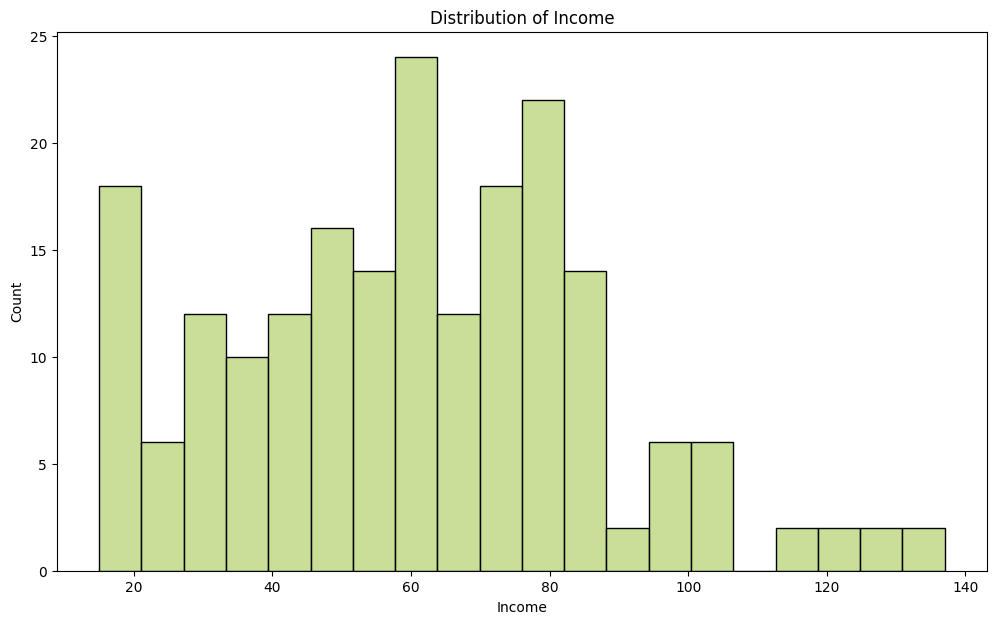

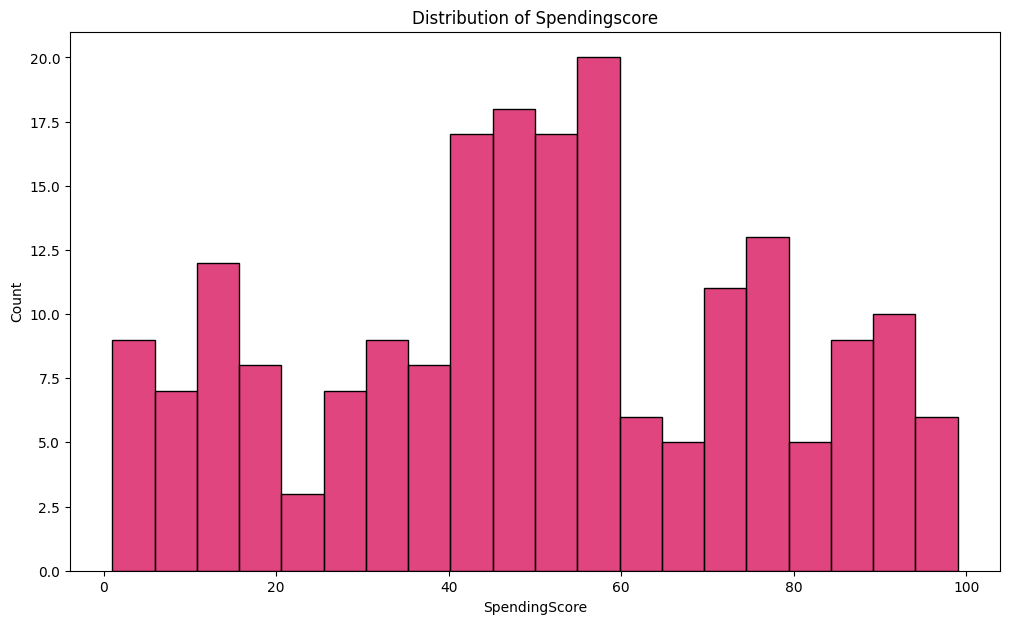

In [380]:
for column, color in zip(diagram_columns, colors):
    visualizer.histplot(column, color)

**Завдання 4** 

Давайте подивимось на ці змінні `Age` , `Income` та `SpendingScore` відносно змінної `Gender`. 
* Побудуємо `pairplot` по всім змінним відностно змінної `Gender`:  
 
* Побудуємо `pairplot` використовуючи `sns.PairGrid` із заданими `(scatterplot)`, `(kdeplot)` та `(kdeplot, lw=1)` по відповідно правому верхньому куту, діагоналі і лівому нижньому кутут відносно змінної `Gender`:  
 

In [381]:
columns = ["Age", "Income", "SpendingScore"]

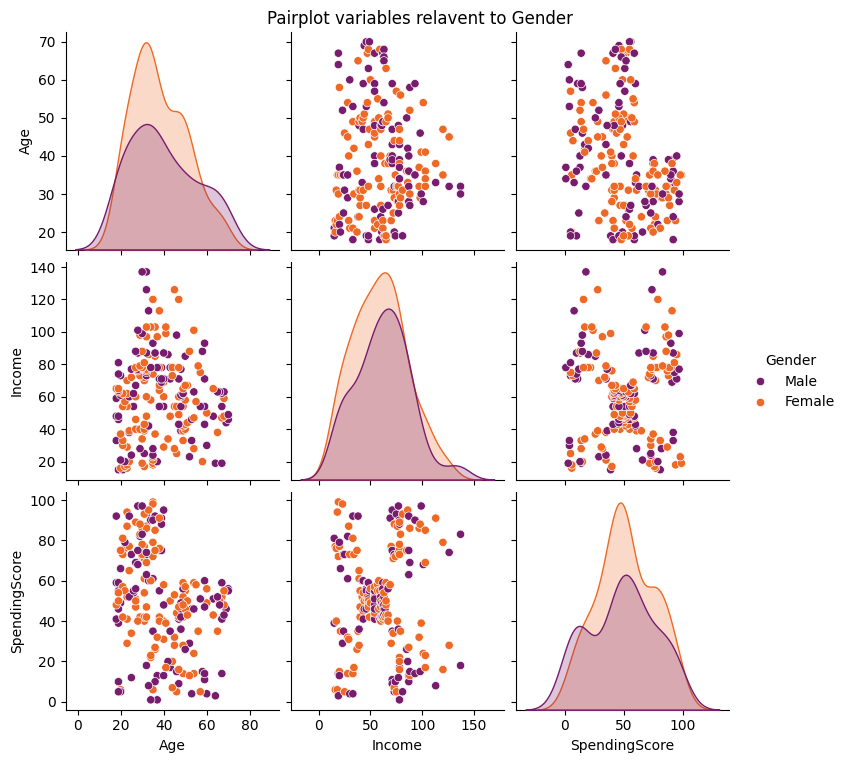

In [382]:
sns.pairplot(customer_df, vars=columns, hue="Gender", palette="inferno", diag_kind="kde")
plt.suptitle("Pairplot variables relavent to Gender", y=1.01)

plt.show()

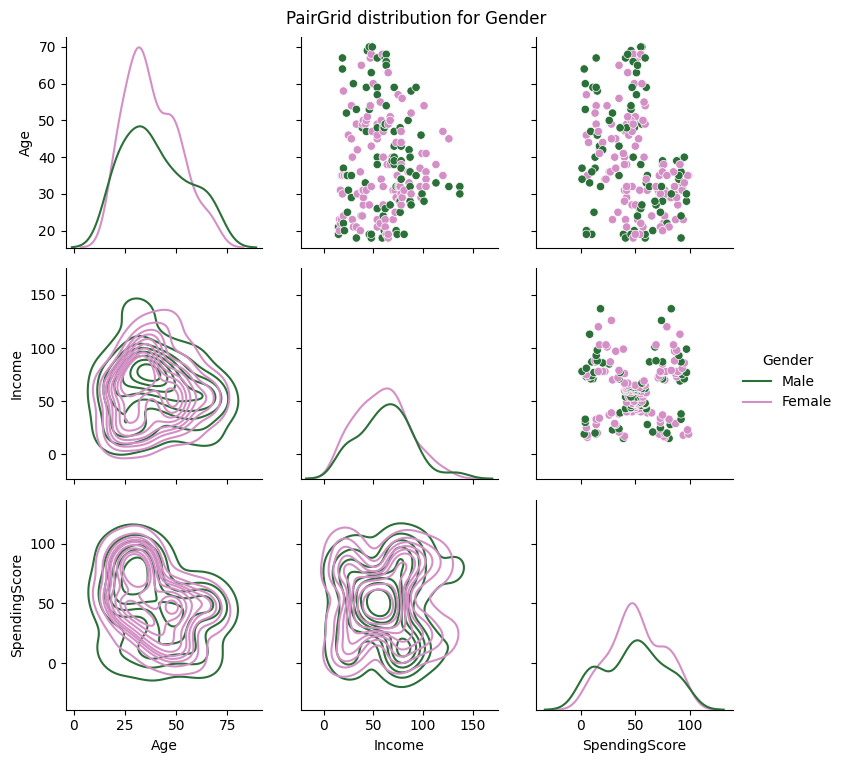

In [383]:
grid = sns.PairGrid(customer_df, vars=columns, hue="Gender", palette="cubehelix")
grid.map_upper(sns.scatterplot)
grid.map_diag(sns.kdeplot)
grid.map_lower(sns.kdeplot, lw=1)
grid.add_legend()
plt.suptitle("PairGrid distribution for Gender", y=1.01)

plt.show()

**Висновки з 1-4 завдання (детальні)**

1. dataset size contains 200 clients records
2. avarage age of clients - 39 years
3. no missed values found in dataset
4. Spending Score has wide distribution

**Завдання 5** 

Проаналізувати змінну `Gender`:
* вивести співвідношення по статям;
* побудувати `countplot` по `Gender`;  
* побудувати `pie`по `Gender'.  

In [384]:
gender_counts = customer_df['Gender'].value_counts()

In [385]:
gender_counts

Gender
Female    112
Male       88
Name: count, dtype: int64

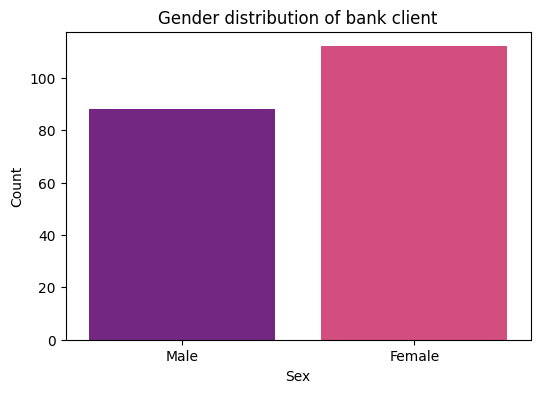

In [386]:
plt.figure(figsize=(6, 4))
sns.countplot(x=customer_df['Gender'], palette=["#7E1891", "#E73879"], )
plt.title('Gender distribution of bank client')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.show()

In [387]:
men_women_colors = ['#EE66A6', '#0D92F4']

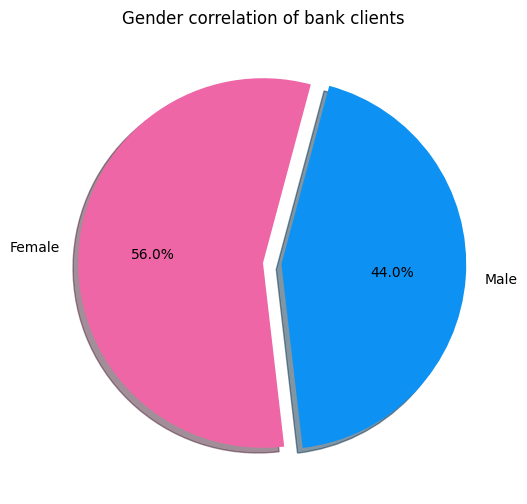

In [388]:
plt.figure(figsize=(6, 6))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        colors=men_women_colors,
        startangle=75,
        explode=(0, 0.1),
        shadow=True
    )
plt.title('Gender correlation of bank clients')

plt.show()

**Завдання 6** 

Побудувати гістограми [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) змінних `Age` та `Income` відносно змінної `Gender` з різними параметрами:
*  подивитись на скільки змінюється візуалізація при різних значеннях параметра `multiple`, наприклад `dodge` та `layer`.

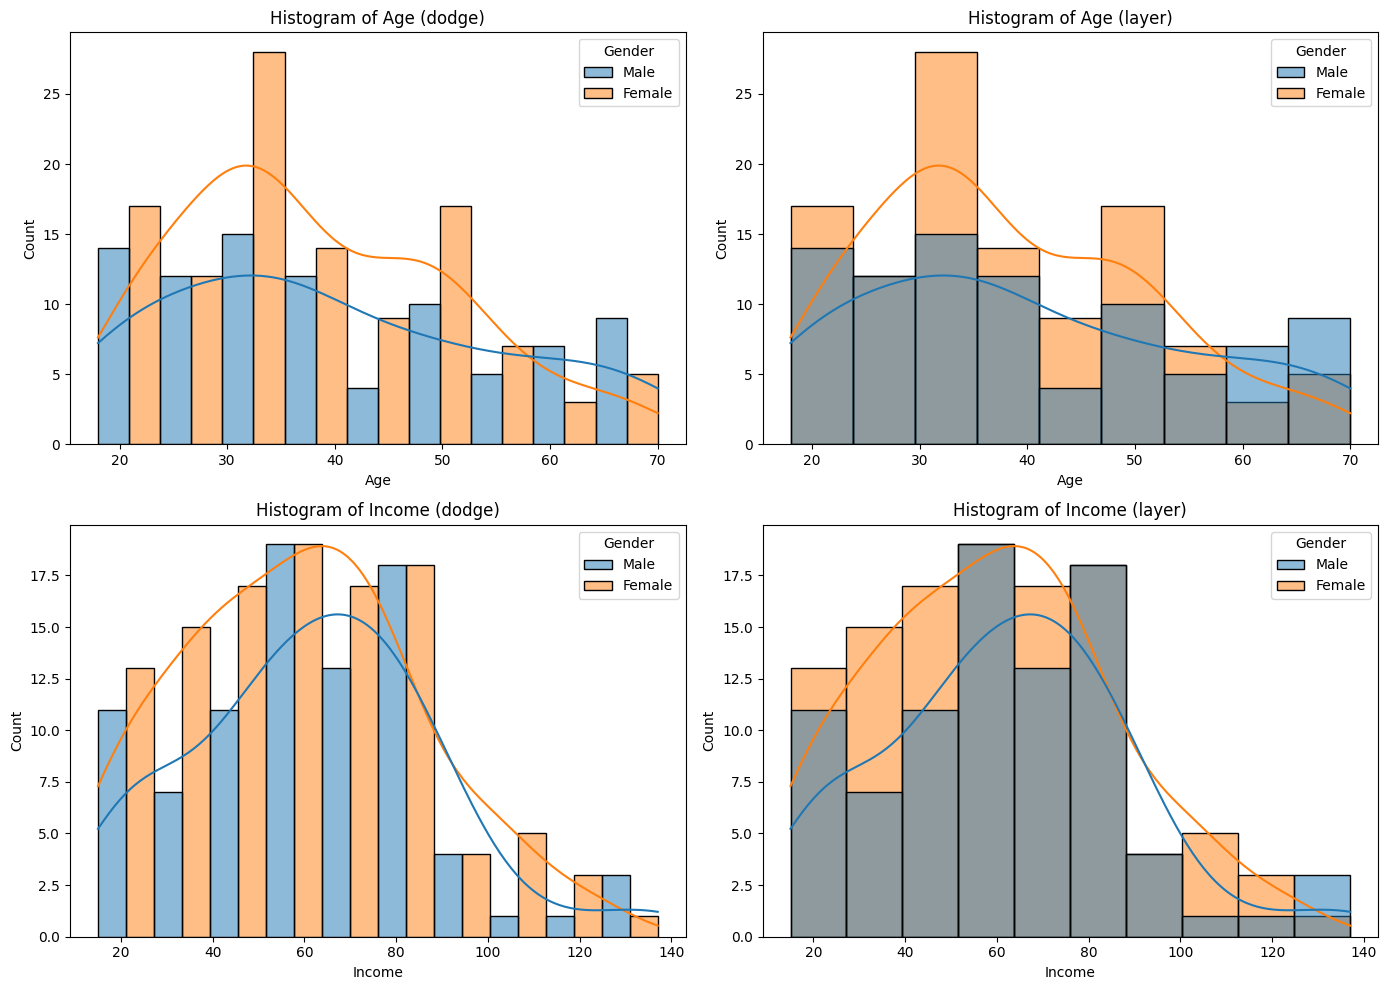

In [389]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=customer_df, x="Age", hue="Gender", multiple="dodge", kde=True, ax=axes[0, 0])
sns.histplot(data=customer_df, x="Age", hue="Gender", multiple="layer", kde=True, ax=axes[0, 1])
sns.histplot(data=customer_df, x="Income", hue="Gender", multiple="dodge", kde=True, ax=axes[1, 0])
sns.histplot(data=customer_df, x="Income", hue="Gender", multiple="layer", kde=True, ax=axes[1, 1])

axes[0, 0].set_title("Histogram of Age (dodge)")
axes[0, 1].set_title("Histogram of Age (layer)")
axes[1, 0].set_title("Histogram of Income (dodge)")
axes[1, 1].set_title("Histogram of Income (layer)")

plt.tight_layout()

plt.show()


**Завдання 7** 

Побудувати гістограми [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) змінної `SpendingScore` відносно змінної `Gender` з різними параметрами:  
* подивитись на скільки змінюється візуалізація при різних значеннях параметра `multiple`, наприклад `dodge` та `layer`. 



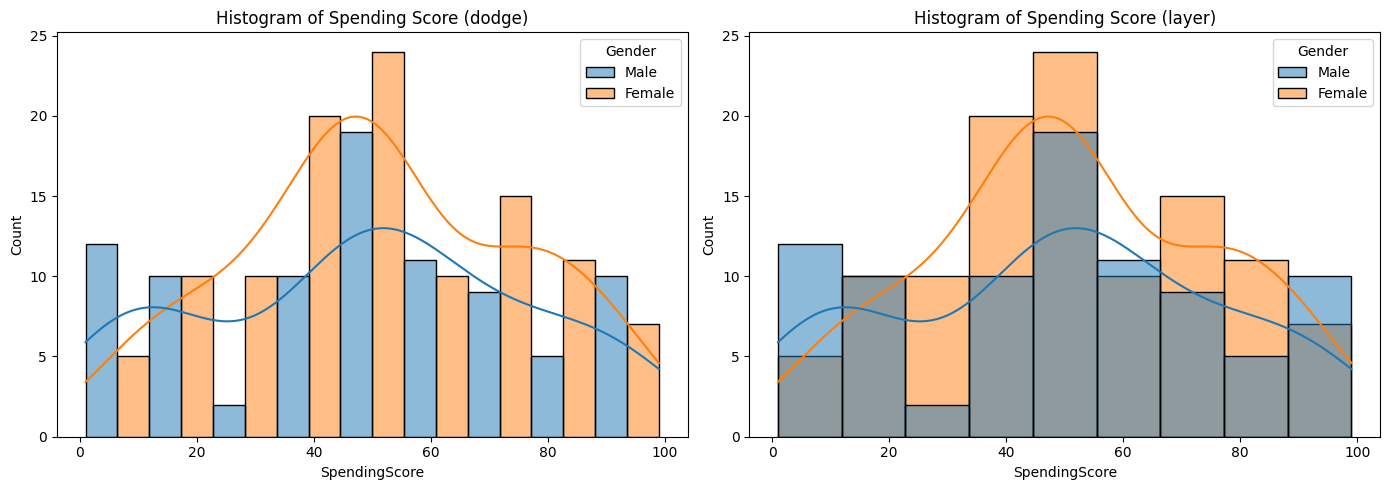

In [390]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=customer_df, x="SpendingScore", hue="Gender", multiple="dodge", kde=True, ax=axes[0])
sns.histplot(data=customer_df, x="SpendingScore", hue="Gender", multiple="layer", kde=True, ax=axes[1])

axes[0].set_title("Histogram of Spending Score (dodge)")
axes[1].set_title("Histogram of Spending Score (layer)")

plt.tight_layout()

plt.show()

**Завдання 8** 

Побудувати `boxplot` по змінній `SpendingScore` і подивитись як відрізняються витрати відностно змінної `Gender`. 

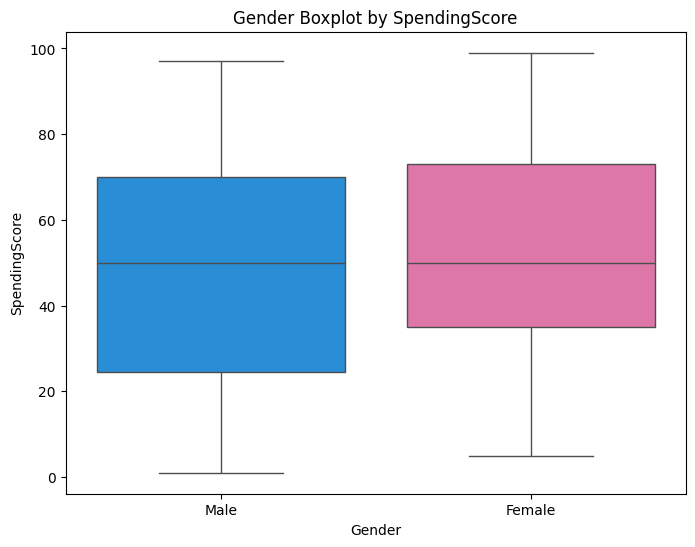

In [391]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=customer_df, x="Gender", y="SpendingScore", palette=men_women_colors[::-1])
plt.title("Gender Boxplot by SpendingScore")

plt.show()


**Висновки з завдання 5 - 8(детальні)**

1. Яке співвідношення груп чоловіків та жінок? - Female: 112 (56%), Male: 88 (44%)
2. Подивитись які можна виділити групи і як розподілені витрати відностно статі людини? - Women show a wider spread in SpendingScore, with groups of low and high spenders.
3. Чи є різниця між витратами у чоловіків та жінок? - Average Spending Score: Women: 51.53, Men: 48.51
4. Targeting younger clients may be effective for marketing promotions.

## K-means Method ##

**Завдання 9** 

Як Ви могли помітити, вибірка, з якою ми працюємо, не містить ключової зміної з вірними мітками. Тому перед початком кластерування необхідно визначити (підібрати) оптимальну кількість кластерів на яке буде проведено розбиття. Для цього необхідно:
1. видалити змінну `Gender`, тому що ... **Чому?**;  
2. задати мінімальну та максимальну кількість кластерів самостійно;  
3. На прикладі алгоритму [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), для ознайомлення з тим як працювати в умовах коли кількість кластерів невідома заздалегіть і немає вірних міток з позначками до якого кластеру відноситься спостереження пропонується використати метод [Elbow](https://coderoad.ru/19197715/Scikit-Learn-K-Means-Elbow-criterion) (додаткові джерела: [article_1](https://medium.com/analytics-vidhya/elbow-method-of-k-means-clustering-algorithm-a0c916adc540#:~:text=K%2Dmeans%20clustering%20is%20an,cluster%20with%20the%20nearest%20centroid.), [article_2](https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/))

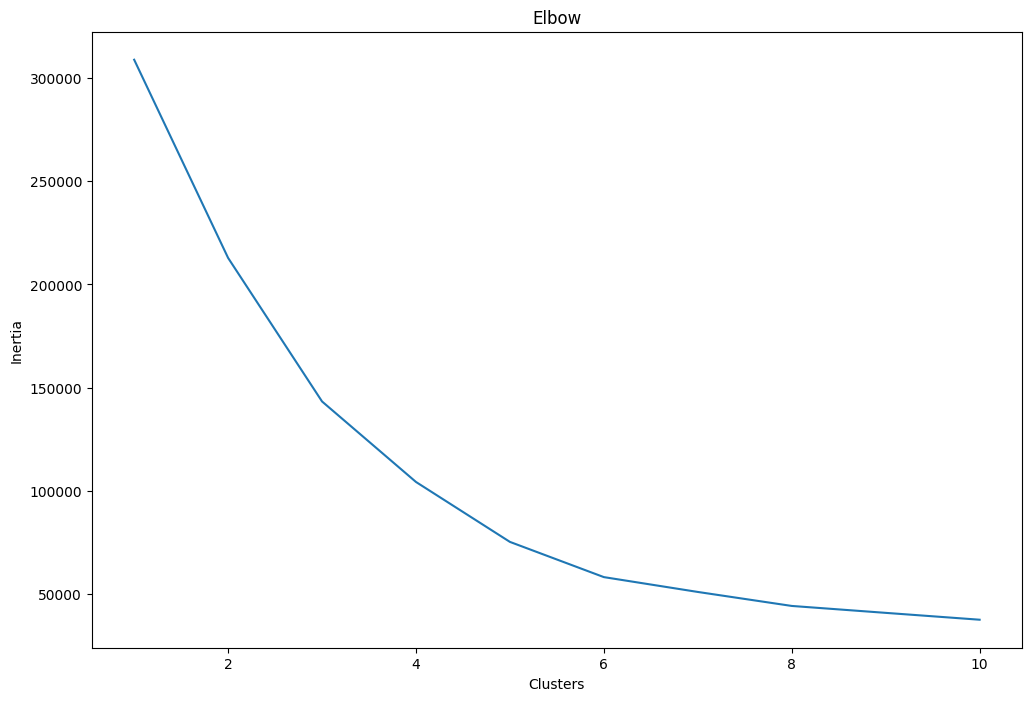

In [392]:
X = customer_df.drop(['Gender'], axis=1)
clusters = []

min_clusters = 1
max_clusters = 10

for claster_count in range(min_clusters, max_clusters + 1):
    kmeans = KMeans(n_clusters=claster_count, random_state=23, n_init=10)
    kmeans.fit(X)
    clusters.append(kmeans.inertia_) 
    
fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(x=list(range(1, 11)), y=clusters, ax=ax)
ax.set_title('Elbow')
ax.set_xlabel('Clusters')
ax.set_ylabel('Inertia')

plt.show()

**Висновки з завдання 9 (детальні)** 

Необхідно навести яка кількість кластерів на Вашу думку є оптимальною (краще розглянути для порівняння делька гіпотез про кількість кластерів) - The most distinct elbow point is 3 and 6, because at this points curve bends the most

**Завдання 10** 

Зробити двовимірну візуалізацію кластеризації методу К-середніх на вибраних Вами двох різних кількостях кластерів використовуючи змінні `Income` та `SpendingScore`. 

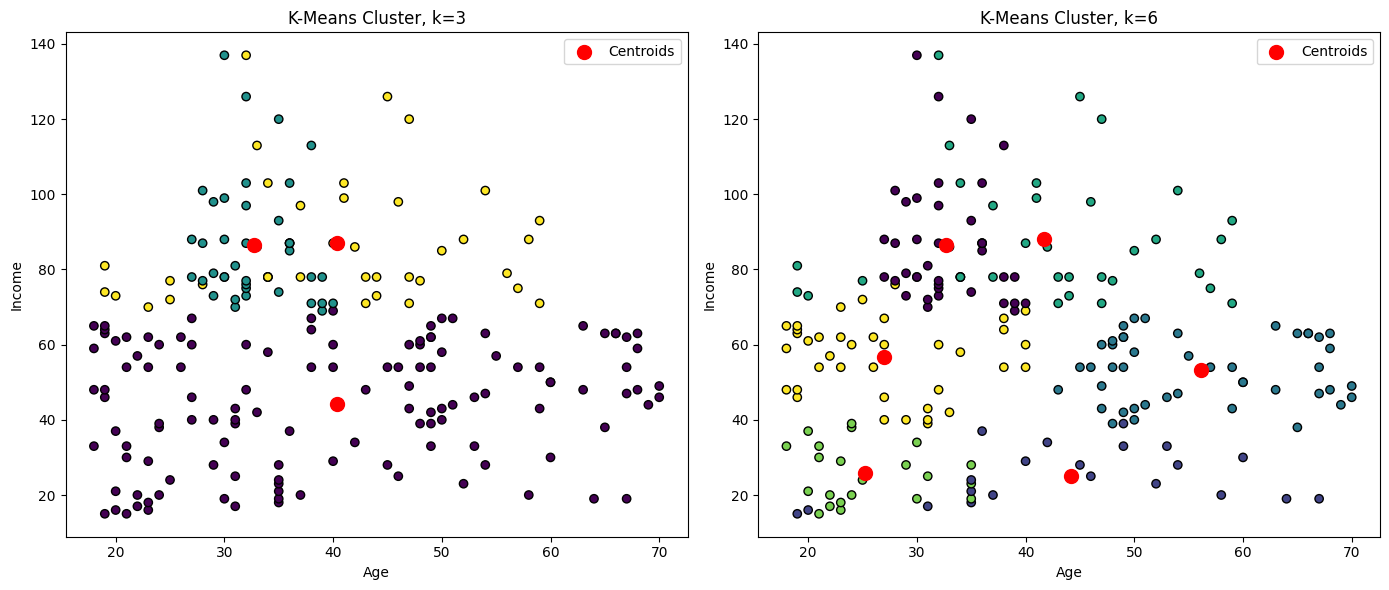

In [393]:
k_values = [3, 6]  

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=23, n_init=10)
    clusters = kmeans.fit_predict(X)
    
    axes[i].scatter(X.iloc[:, 0], X.iloc[:, 1], c=clusters, cmap='viridis', edgecolor='k')
    axes[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red', marker='o', label='Centroids')
    axes[i].set_title(f'K-Means Cluster, k={k}')
    axes[i].set_xlabel(X.columns[0])
    axes[i].set_ylabel(X.columns[1])
    axes[i].legend()

plt.tight_layout()
plt.show()

In [394]:
customer_df

,Gender,Age,Income,SpendingScore
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


**Завдання 11** 

Зробити візуалізацію кластеризації методу К-середніх на вибраних Вами двох різних кількостях кластерів використовуючи [scatter_3d](https://plotly.com/python/3d-scatter-plots/).

In [395]:
k_values = [3, 6]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=23, n_init=10)
    clusters = kmeans.fit_predict(X)

    fig = px.scatter_3d(
        X,
        x=X.columns[0],
        y=X.columns[1],
        z=X.columns[2],
        color=clusters.astype(str),
        title=f"K-Means Clustering (k={k})",
        labels={'color': 'Cluster'}
    )

    centers = kmeans.cluster_centers_
    fig.add_scatter3d(
        x=centers[:, 0],
        y=centers[:, 1],
        z=centers[:, 2],
        mode='markers',
        marker=dict(size=8, color='red', symbol='x'),
        name='Centroids'
    )
    
    fig.show()

**Висновки з завдання 10 - 11 (детальні)** 

1. Визначитась з отриманих візуалізацій яка кількість кластерів є оптимальною на Вашу думку і провести аналіз кластерів, що Ви отримали. - Based on 2D and 3D visualizations, the optimal number of clusters is 6. Because it's clear and well-separated groups.
2. With k=6, we can see different types of customers like: Young, high spenders, Older, low spenders, High-income but frugal clients

## Agglomerative clustering ##

Розглянемо ще один підхід до кластеризації - [агломеративну ієрархічну кластеризацію](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

**Завдання 12** 

Кластеризуйте датасет за допомогою [агломеративної ієрархічнуої кластеризації](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

Мінімально необхідні параметри, що треба налаштувати:  
* `n_clusters`: параметр, який відповідає за кільксіть кластерів на яку буде проведено розбиття вибірки;  
* `linkage`: параметр зв’язку. Цей параметр визначає, яку відстань використовувати між наборами спостережень.
* перевірте як працює цей метод з різними параметрами `linkage`  
* після кожної зміни параметрів - візуалізувати розбиття на кластери

Розрахувати матрицю відстаней для нашого набору даних:
* за допомогою методу [hierarchy.linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html) і матриці відстаней кластеризувати дані з різними значеннями параметра `method`
* за допомогою методу [hierarchy.dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html) візуалізувати отримані результати кластеризації у вигляді дендрограм


In [396]:
X = customer_df[['Income', 'SpendingScore']].values

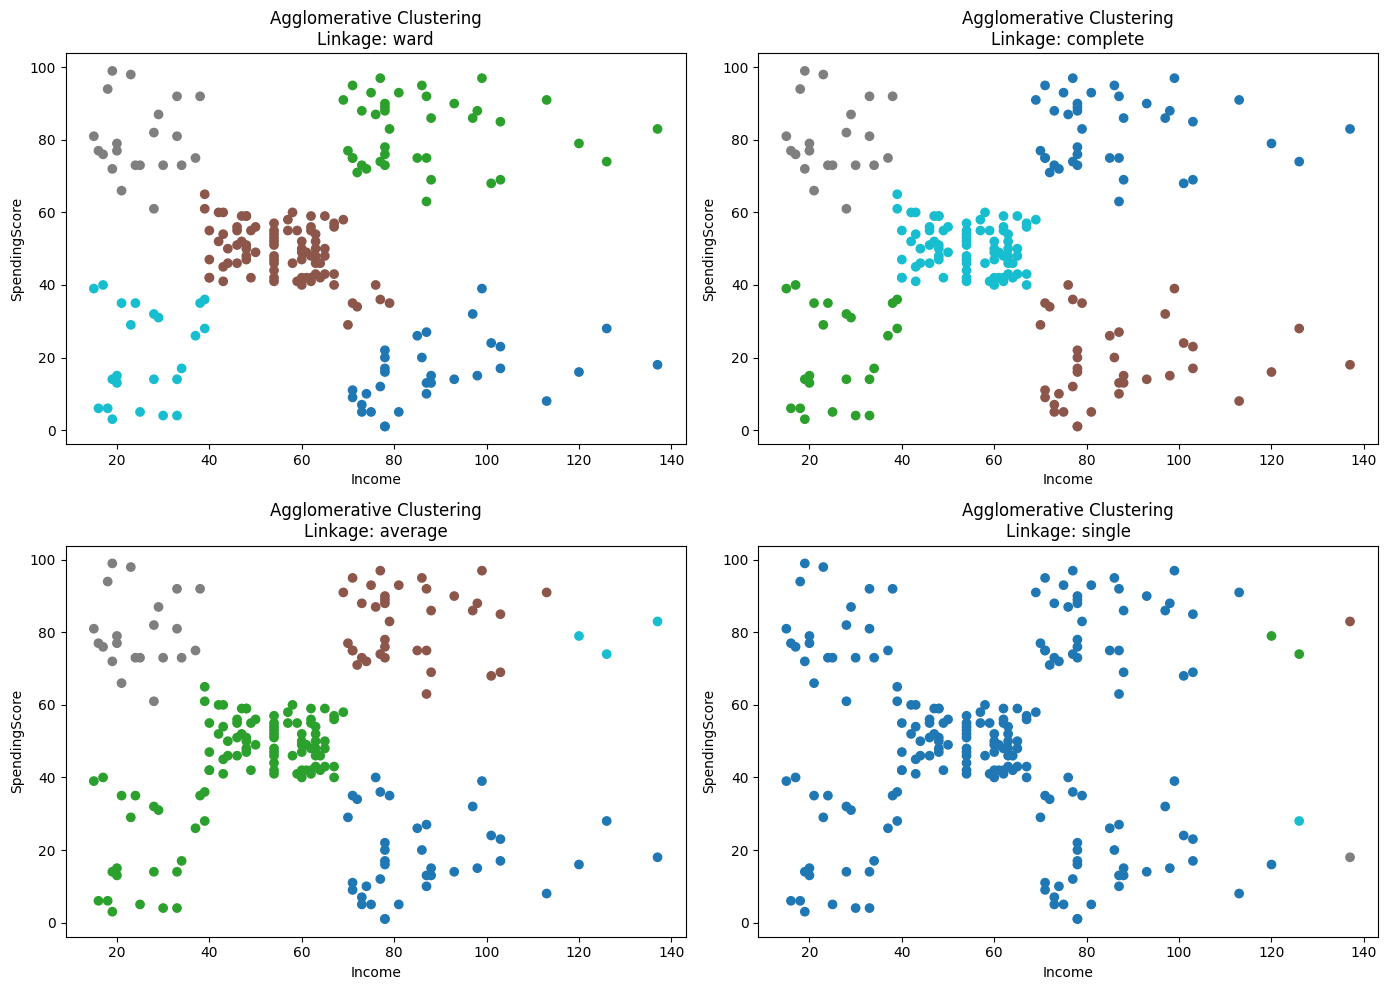

In [397]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, method in enumerate(linkage_methods):
    model = AgglomerativeClustering(n_clusters=5, linkage=method)
    labels = model.fit_predict(X_scaled)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10')
    axes[i].set_title(f'Agglomerative Clustering\nLinkage: {method}')
    axes[i].set_xlabel('Income')
    axes[i].set_ylabel('SpendingScore')

plt.tight_layout()
plt.show()

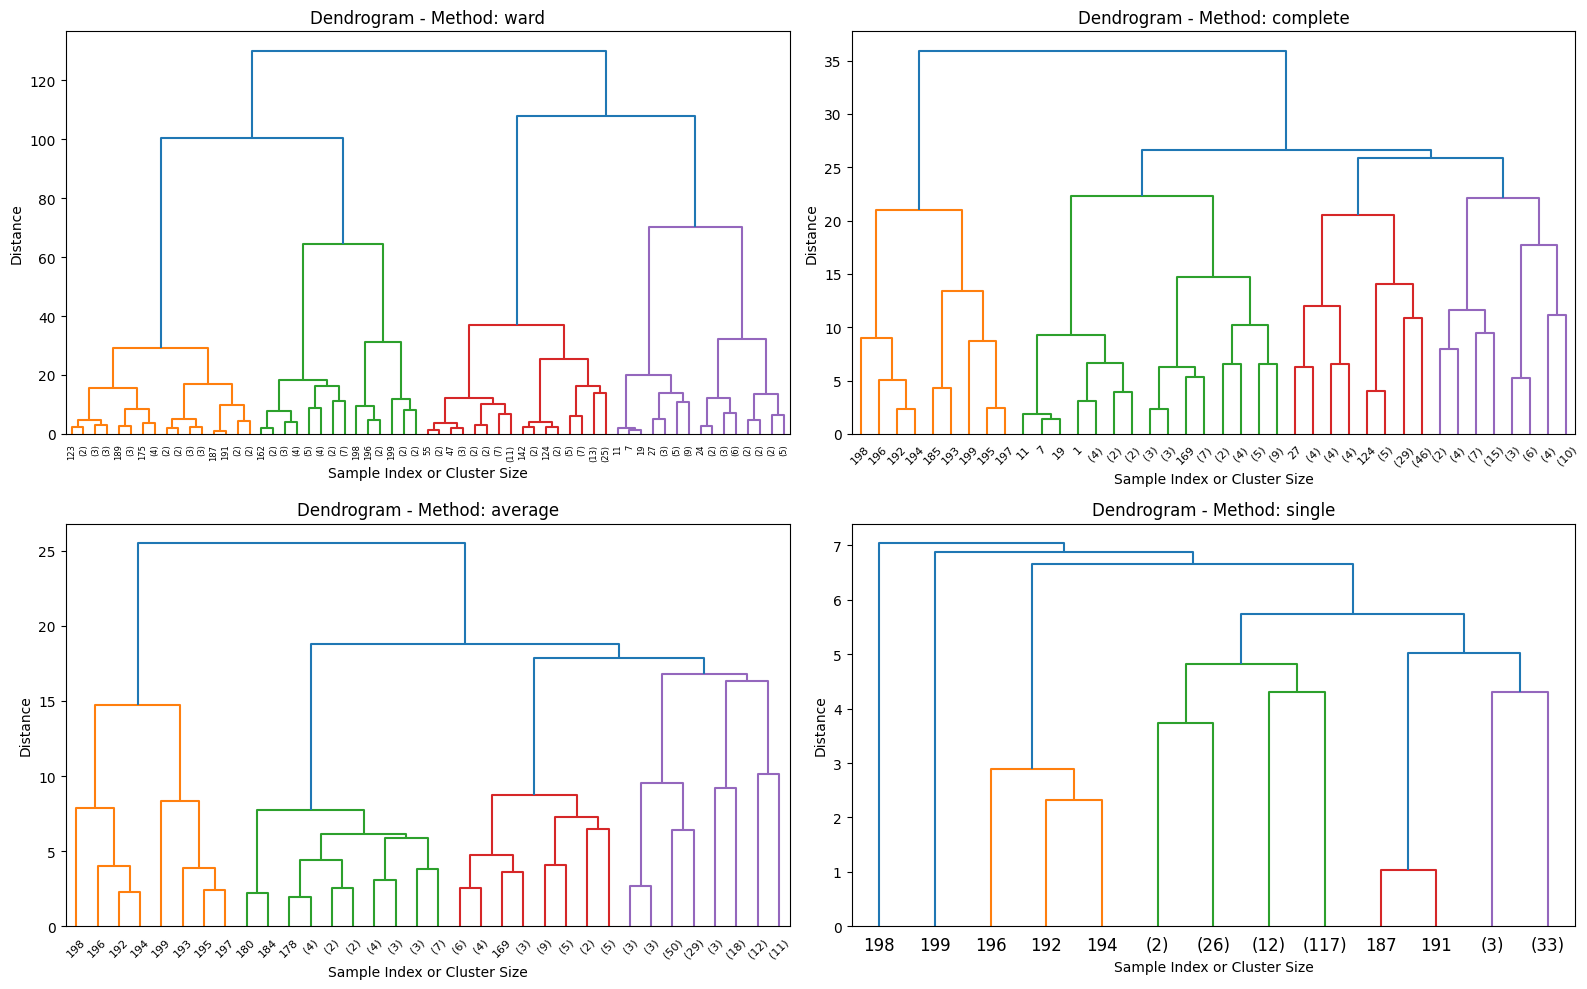

In [398]:
dist_matrix = distance_matrix(X_scaled, X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, method in enumerate(linkage_methods):
    Z = hierarchy.linkage(dist_matrix, method=method)
    hierarchy.dendrogram(Z, ax=axes[i], truncate_mode='level', p=5)
    axes[i].set_title(f'Dendrogram - Method: {method}')
    axes[i].set_xlabel('Sample Index or Cluster Size')
    axes[i].set_ylabel('Distance')

plt.tight_layout()
plt.show()



**Висновки з завдання 12 (детальні)**

1. Different linkage types give different results
2. Ward and complete - clear, well-separated cluster, most reliable and gives meaningful customer groups
3. Average - give some overlap
4. Single - stretched clusters, not useful

**Завдання 13** 

А тепер зробимо порівняльний аналіз отриманих результатів кластеризації розглянутими методами:  
* В фінальних візуалізаціях треба використовувати **однакову** (на вашу думку оптимальну) кількість кластерів!!!  

In [399]:
X = customer_df[['Income', 'SpendingScore']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
models = {
    "KMeans (k=5)": KMeans(n_clusters=5, random_state=44, n_init=10),
    "Agglomerative (ward)": AgglomerativeClustering(n_clusters=5, linkage='ward'),
    "Agglomerative (complete)": AgglomerativeClustering(n_clusters=5, linkage='complete'),
    "Agglomerative (average)": AgglomerativeClustering(n_clusters=5, linkage='average'),
    "Agglomerative (single)": AgglomerativeClustering(n_clusters=5, linkage='single')
}

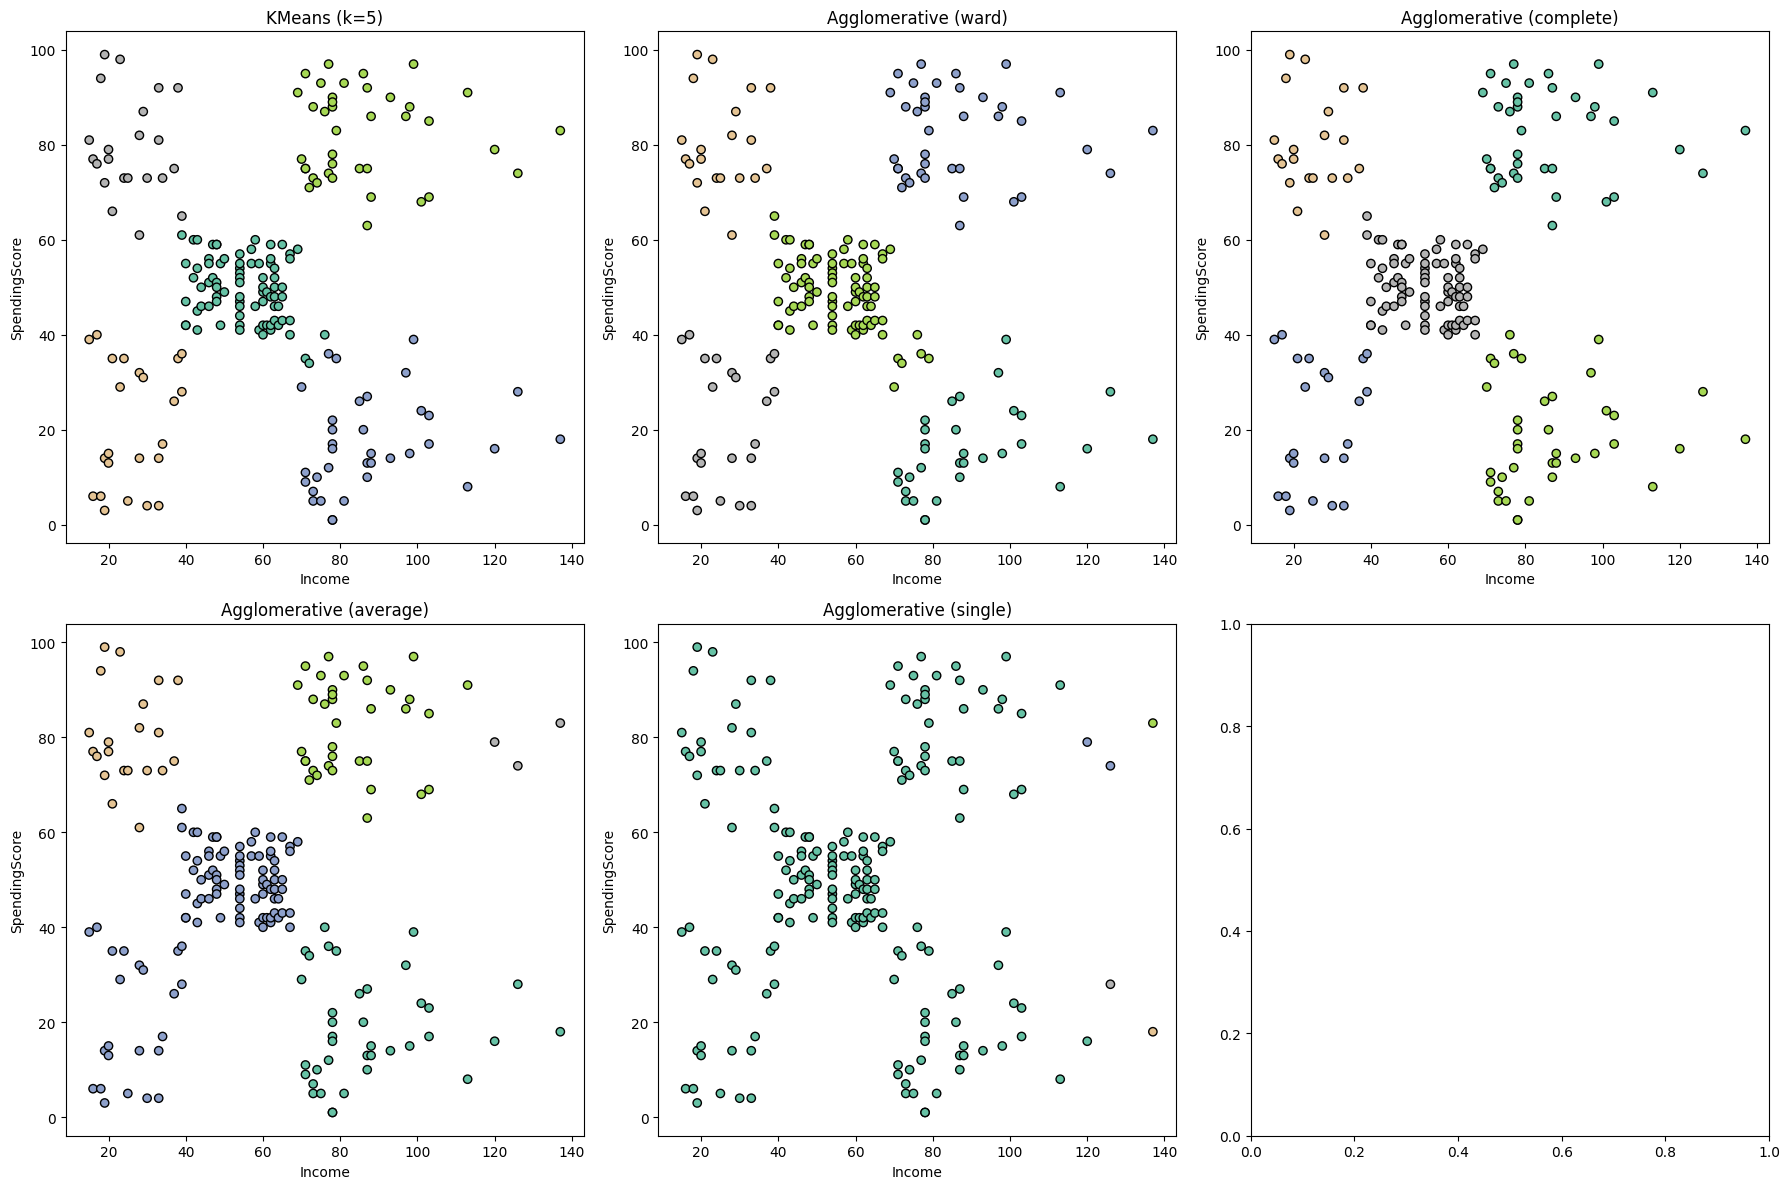

In [401]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    if 'KMeans' in name:
        labels = model.fit_predict(X_scaled)
    else:
        labels = model.fit_predict(X_scaled)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='Set2', edgecolor='k')
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Income')
    axes[i].set_ylabel('SpendingScore')

plt.tight_layout()
plt.show()

**Висновки з завдання 13 (детальні)**

1. KMeans (k=5) - clear and rounded clusters
2. Agglomerative (ward) - Similar to KMeans
3. Agglomerative (complete) - shapes are less smooth
4. Agglomerative (average) - have some overlap
5. Agglomerative (single) - Long, chained clusters, bag for this dataset